In [1]:
import pandas as pd
import numpy as np
import pickle
from sklearn.decomposition import PCA


In [2]:
path = "../../../../../../../../../s/project/yeast_gxg/data/orthrus_data/"

In [3]:
mrl_isoform = np.load( path + 'mrl_isoform_resolved.npz')

print(mrl_isoform.files)

print("\nArray shapes:")
print(f"X shape: {mrl_isoform['X'].shape}")
print(f"y shape: {mrl_isoform['y'].shape}")
print(f"genes shape: {mrl_isoform['genes'].shape}")

print(f"\nFirst few y values: {mrl_isoform['y'][:10]}")

print(f"\nX dimensions: {mrl_isoform['X'].ndim}")
if mrl_isoform['X'].ndim == 3:
    print(f"X first sample shape: {mrl_isoform['X'][0].shape}")
    print(f"X first sample, first feature vector: {mrl_isoform['X'][0, 0, :5]}")  # First 5 features
elif mrl_isoform['X'].ndim == 2:
    print(f"X first sample (first 10 features): {mrl_isoform['X'][0, :10]}")

['X', 'y', 'genes']

Array shapes:
X shape: (11693, 12288, 6)
y shape: (11693,)
genes shape: (11693,)

First few y values: [5.40141546 3.33709259 5.41937329 5.74227841 5.32184319 5.95879864
 3.3906673  2.96185415 3.62454262 3.8039584 ]

X dimensions: 3
X first sample shape: (12288, 6)
X first sample, first feature vector: [1. 0. 0. 0. 0.]


In [ ]:
def create_gene_embedding_dataframe(embeddings, genes, method_name="mrl_pca"):
    """
    Create a DataFrame with gene_ids as index and embeddings as columns
    """
    # Create column names for embedding dimensions
    n_dims = embeddings.shape[1]
    column_names = [f'PCA_{i}' for i in range(n_dims)]
    
    # Create DataFrame
    df = pd.DataFrame(embeddings, columns=column_names)
    df['gene_id'] = genes
    df = df.set_index('gene_id')

    # Keep only the first occurrence of each gene
    df = df[~df.index.duplicated(keep='first')]
    
    return df
    
def isoform_to_gene_embeddings_pca(X, genes, n_components=128):
    """
    Use PCA to create gene embeddings from isoform data
    """
    X_flat = X.reshape(X.shape[0], -1)
    
    pca = PCA(n_components=n_components)
    gene_embeddings = pca.fit_transform(X_flat)
    
    print(f"Explained variance ratio (first 10): {pca.explained_variance_ratio_[:10]}")
    print(f"Total explained variance: {np.sum(pca.explained_variance_ratio_):.3f}")
    
    return gene_embeddings, pca

In [58]:
pca_embeddings, pca_model = isoform_to_gene_embeddings_pca(mrl_isoform['X'], mrl_isoform['genes'], n_components=1024)
print(f"PCA embeddings shape: {pca_embeddings.shape}")

Explained variance ratio (first 10): [0.07037991 0.02956103 0.02884267 0.0200473  0.00938821 0.00695937
 0.00686706 0.00641901 0.0052162  0.00419124]
Total explained variance: 0.547
PCA embeddings shape: (11693, 1024)


In [59]:
pca_embeddings = create_gene_embedding_dataframe(pca_embeddings, mrl_isoform['genes'], method_name="mrl_pca")
pca_embeddings

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_1014,PCA_1015,PCA_1016,PCA_1017,PCA_1018,PCA_1019,PCA_1020,PCA_1021,PCA_1022,PCA_1023
gene_id,,,,,,,,,,,,,,,,,,,,,
DPM1,-10.361529,-8.008942,-4.610142,-1.607383,-1.603568,-2.098625,7.689998,-2.192731,2.336392,4.715554,...,0.022487,0.305170,0.569447,-0.197715,0.003504,0.609191,-0.601173,0.700878,-0.069012,-0.624215
SCYL3,7.433342,-0.213358,20.708685,10.193992,0.171460,1.669660,1.956169,5.487548,-4.517016,4.052445,...,-1.083318,1.592152,-0.695606,-0.268535,-0.832595,-0.043647,-0.336463,-0.197603,0.918567,-1.222053
CFH,-4.719111,0.235217,15.849966,5.422871,-5.956711,-4.142274,-3.241006,-1.927898,3.192172,5.278052,...,0.024634,-0.878096,-0.204348,-0.371186,0.583724,0.074019,0.195284,0.029260,-0.364617,0.338012
FUCA2,0.285524,-13.308829,-7.988857,8.813583,-5.129483,-1.180700,5.993691,-2.090514,-1.312564,2.291228,...,0.512288,-0.609226,-0.376697,-2.429227,-0.457749,1.204666,-0.138784,-0.243349,-0.626754,0.760533
GCLC,-0.833933,8.637342,-4.698057,7.718352,-5.330405,4.518104,-0.847529,-1.617334,-0.353551,-0.556158,...,-1.138368,-0.036986,-0.196883,0.700764,-0.192859,0.193477,-0.741757,0.106658,-0.772262,-0.614809
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PTP4A1,15.378114,5.489214,-2.850180,1.783017,9.694752,4.618853,0.581023,-7.849329,0.445557,1.779173,...,0.102032,-0.392569,0.318031,-0.237366,0.245299,-0.447498,0.008912,-0.004368,0.075978,0.110181
NOTCH2NLB,25.368298,-0.191846,9.848917,-14.466546,-5.134555,-1.124350,-3.638568,-11.873979,-1.226618,-3.579755,...,-1.816205,1.132883,1.069325,-1.368840,-0.135387,1.602001,-0.615799,-2.252416,-1.796862,-1.267031
CHTF8,-11.902716,-0.075104,3.761488,-3.102909,0.091446,-3.052718,-3.424348,-1.653272,1.053344,-0.681357,...,0.092741,0.451692,0.188406,-0.485953,-0.080229,-0.119356,0.473873,0.679258,-0.062098,-0.334260


In [60]:
emogi_predictions = pd.read_csv('../../../../../../../../s/project/gene_embedding/input_data/cancer_eval/emogi_predictions.tsv', sep='\t')
emogi_predictions

,ID,Name,label,Prob_pos_1,Prob_pos_2,Prob_pos_3,Prob_pos_4,Prob_pos_5,Prob_pos_6,Prob_pos_7,...,Prob_pos_9,Prob_pos_10,Num_Pos,Mean_Pred,Std_Pred,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene,ONGene_Oncogene
0,ENSG00000100393,EP300,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
1,ENSG00000133703,KRAS,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
2,ENSG00000155657,TTN,False,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,False,True,False,False,False
3,ENSG00000284792,PTEN,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
4,ENSG00000039068,CDH1,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13622,ENSG00000266200,PNLIPRP2,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13623,ENSG00000125375,DMAC2L,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13624,ENSG00000173662,TAS1R1,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13625,ENSG00000197084,LCE1C,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False


In [61]:
pca_embeddings

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_1014,PCA_1015,PCA_1016,PCA_1017,PCA_1018,PCA_1019,PCA_1020,PCA_1021,PCA_1022,PCA_1023
gene_id,,,,,,,,,,,,,,,,,,,,,
DPM1,-10.361529,-8.008942,-4.610142,-1.607383,-1.603568,-2.098625,7.689998,-2.192731,2.336392,4.715554,...,0.022487,0.305170,0.569447,-0.197715,0.003504,0.609191,-0.601173,0.700878,-0.069012,-0.624215
SCYL3,7.433342,-0.213358,20.708685,10.193992,0.171460,1.669660,1.956169,5.487548,-4.517016,4.052445,...,-1.083318,1.592152,-0.695606,-0.268535,-0.832595,-0.043647,-0.336463,-0.197603,0.918567,-1.222053
CFH,-4.719111,0.235217,15.849966,5.422871,-5.956711,-4.142274,-3.241006,-1.927898,3.192172,5.278052,...,0.024634,-0.878096,-0.204348,-0.371186,0.583724,0.074019,0.195284,0.029260,-0.364617,0.338012
FUCA2,0.285524,-13.308829,-7.988857,8.813583,-5.129483,-1.180700,5.993691,-2.090514,-1.312564,2.291228,...,0.512288,-0.609226,-0.376697,-2.429227,-0.457749,1.204666,-0.138784,-0.243349,-0.626754,0.760533
GCLC,-0.833933,8.637342,-4.698057,7.718352,-5.330405,4.518104,-0.847529,-1.617334,-0.353551,-0.556158,...,-1.138368,-0.036986,-0.196883,0.700764,-0.192859,0.193477,-0.741757,0.106658,-0.772262,-0.614809
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PTP4A1,15.378114,5.489214,-2.850180,1.783017,9.694752,4.618853,0.581023,-7.849329,0.445557,1.779173,...,0.102032,-0.392569,0.318031,-0.237366,0.245299,-0.447498,0.008912,-0.004368,0.075978,0.110181
NOTCH2NLB,25.368298,-0.191846,9.848917,-14.466546,-5.134555,-1.124350,-3.638568,-11.873979,-1.226618,-3.579755,...,-1.816205,1.132883,1.069325,-1.368840,-0.135387,1.602001,-0.615799,-2.252416,-1.796862,-1.267031
CHTF8,-11.902716,-0.075104,3.761488,-3.102909,0.091446,-3.052718,-3.424348,-1.653272,1.053344,-0.681357,...,0.092741,0.451692,0.188406,-0.485953,-0.080229,-0.119356,0.473873,0.679258,-0.062098,-0.334260


In [62]:
NCG_Known_Genes = emogi_predictions[['Name', "NCG_Known_Cancer_Gene"]]
merged = pca_embeddings.merge(NCG_Known_Genes, left_index=True, right_on='Name', how='inner')
merged.set_index('Name', inplace=True)
merged

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_1015,PCA_1016,PCA_1017,PCA_1018,PCA_1019,PCA_1020,PCA_1021,PCA_1022,PCA_1023,NCG_Known_Cancer_Gene
Name,,,,,,,,,,,,,,,,,,,,,
DPM1,-10.361529,-8.008942,-4.610142,-1.607383,-1.603568,-2.098625,7.689998,-2.192731,2.336392,4.715554,...,0.305170,0.569447,-0.197715,0.003504,0.609191,-0.601173,0.700878,-0.069012,-0.624215,False
SCYL3,7.433342,-0.213358,20.708685,10.193992,0.171460,1.669660,1.956169,5.487548,-4.517016,4.052445,...,1.592152,-0.695606,-0.268535,-0.832595,-0.043647,-0.336463,-0.197603,0.918567,-1.222053,False
CFH,-4.719111,0.235217,15.849966,5.422871,-5.956711,-4.142274,-3.241006,-1.927898,3.192172,5.278052,...,-0.878096,-0.204348,-0.371186,0.583724,0.074019,0.195284,0.029260,-0.364617,0.338012,False
FUCA2,0.285524,-13.308829,-7.988857,8.813583,-5.129483,-1.180700,5.993691,-2.090514,-1.312564,2.291228,...,-0.609226,-0.376697,-2.429227,-0.457749,1.204666,-0.138784,-0.243349,-0.626754,0.760533,False
GCLC,-0.833933,8.637342,-4.698057,7.718352,-5.330405,4.518104,-0.847529,-1.617334,-0.353551,-0.556158,...,-0.036986,-0.196883,0.700764,-0.192859,0.193477,-0.741757,0.106658,-0.772262,-0.614809,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SCO2,-11.021691,-8.526528,-5.202515,-2.475116,-1.106725,-2.811286,7.074593,0.870503,3.028499,-0.628025,...,0.581469,0.556975,-0.411137,-0.363031,-0.881231,-0.363249,-0.050138,0.411463,-0.094483,False
TBCE,-3.199916,-0.195192,13.523295,6.196819,-5.897826,-0.775914,0.624610,1.177227,2.232309,3.613913,...,0.382575,-0.288040,-1.521664,-0.435939,0.715817,0.291552,0.060561,-0.201344,-0.446844,False
ABCF2,16.090095,17.135822,-9.145933,4.259971,6.373613,1.688988,-0.188709,2.161776,3.379265,-0.509944,...,1.510165,-0.412863,-0.164607,0.906598,1.542896,0.001675,1.729443,-0.286221,0.871321,False


In [63]:
merged['NCG_Known_Cancer_Gene'].value_counts()

NCG_Known_Cancer_Gene
False    5610
True      331
Name: count, dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder

X = merged.drop('NCG_Known_Cancer_Gene', axis=1)
y = merged['NCG_Known_Cancer_Gene']

le = LabelEncoder()
y_encoded = le.fit_transform(y) 

print(f"Features shape: {X.shape}")
print(f"Target distribution:")
print(pd.Series(y_encoded).value_counts())

# Split the data 80-20
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded  # Ensures balanced split
)

print(f"\nTrain set: {X_train.shape}, Test set: {X_test.shape}")
print(f"Train target distribution: {pd.Series(y_train).value_counts()}")
print(f"Test target distribution: {pd.Series(y_test).value_counts()}")

Features shape: (5941, 1024)
Target distribution:
0    5610
1     331
Name: count, dtype: int64

Train set: (4752, 1024), Test set: (1189, 1024)
Train target distribution: 0    4487
1     265
Name: count, dtype: int64
Test target distribution: 0    1123
1      66
Name: count, dtype: int64


In [65]:
# Try different models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': HistGradientBoostingClassifier(random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n=== {name} ===")
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # Probability of positive class
    
    # Calculate metrics
    auc_score = roc_auc_score(y_test, y_prob)
    
    print(f"AUC Score: {auc_score:.3f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Not Cancer Gene', 'Cancer Gene']))
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    # Store results
    results[name] = {
        'model': model,
        'auc': auc_score,
        'predictions': y_pred,
        'probabilities': y_prob
    }


=== Random Forest ===
AUC Score: 0.602

Classification Report:
                 precision    recall  f1-score   support

Not Cancer Gene       0.94      1.00      0.97      1123
    Cancer Gene       0.00      0.00      0.00        66

       accuracy                           0.94      1189
      macro avg       0.47      0.50      0.49      1189
   weighted avg       0.89      0.94      0.92      1189


Confusion Matrix:
[[1123    0]
 [  66    0]]

=== Gradient Boosting ===


/opt/modules/i12g/anaconda/envs/ege_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/modules/i12g/anaconda/envs/ege_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/modules/i12g/anaconda/envs/ege_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{m

AUC Score: 0.559

Classification Report:
                 precision    recall  f1-score   support

Not Cancer Gene       0.94      1.00      0.97      1123
    Cancer Gene       0.00      0.00      0.00        66

       accuracy                           0.94      1189
      macro avg       0.47      0.50      0.49      1189
   weighted avg       0.89      0.94      0.92      1189


Confusion Matrix:
[[1123    0]
 [  66    0]]


/opt/modules/i12g/anaconda/envs/ege_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/modules/i12g/anaconda/envs/ege_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/modules/i12g/anaconda/envs/ege_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{m

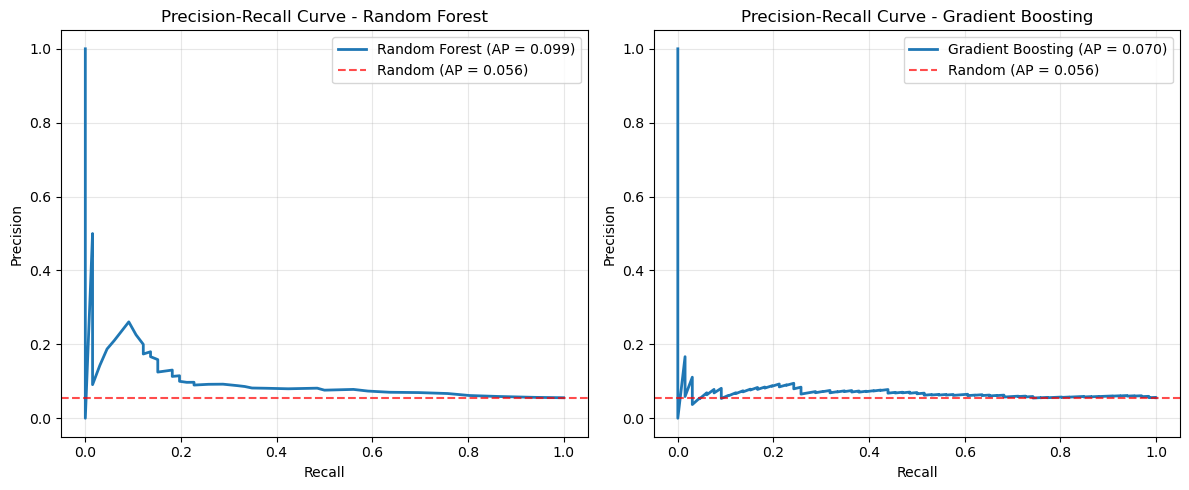

Average Precision Scores:
Random Forest: 0.099
Gradient Boosting: 0.070


In [67]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Create precision-recall curves for both models
plt.figure(figsize=(12, 5))

# Plot for both models
for i, (name, result) in enumerate(results.items()):
    plt.subplot(1, 2, i+1)
    
    # Calculate precision-recall curve
    precision, recall, _ = precision_recall_curve(y_test, result['probabilities'])
    ap_score = average_precision_score(y_test, result['probabilities'])
    
    # Plot PR curve
    plt.plot(recall, precision, linewidth=2, label=f'{name} (AP = {ap_score:.3f})')
    
    # Add baseline (random classifier)
    baseline = sum(y_test) / len(y_test)  # Proportion of positive class
    plt.axhline(y=baseline, color='red', linestyle='--', alpha=0.7, 
                label=f'Random (AP = {baseline:.3f})')
    
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve - {name}')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print average precision scores
print("Average Precision Scores:")
for name, result in results.items():
    ap_score = average_precision_score(y_test, result['probabilities'])
    print(f"{name}: {ap_score:.3f}")